# Phase 1f - Paper-Ready Results Synthesis

Combines four in-distribution result sources only:

1. Original Phase 1 leaderboard.
2. Grouped cross-validation.
3. Current-model ablation.
4. Hybrid / PINN-feature results.

Phase 4 / Kirkaldy external validation is intentionally excluded and should be
handled separately.



## 0. Imports and Config



In [18]:
import json
import math
import os
import zipfile
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORKING = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
INPUT = Path("/kaggle/input") if Path("/kaggle/input").exists() else Path(".")
RUN_TAG = "phase1f_paper_ready_synthesis_" + datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = WORKING / RUN_TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.family": "DejaVu Sans",
})

print("Run tag:", RUN_TAG)
print("Output:", OUT_DIR)



Run tag: phase1f_paper_ready_synthesis_20260625_092740
Output: /kaggle/working/phase1f_paper_ready_synthesis_20260625_092740


## 1. File Discovery



In [19]:
def find_files(name):
    roots = [INPUT, WORKING, Path(".")]
    hits = []
    for root in roots:
        if root.exists():
            hits.extend(root.rglob(name))
    return sorted(set(hits), key=lambda p: (len(str(p)), str(p)))


def read_csv_anywhere(name, required=False):
    hits = find_files(name)
    if hits:
        print(f"{name}: {hits[0]}")
        return pd.read_csv(hits[0]), hits[0]

    # Search inside zip files.
    zip_hits = []
    for root in [INPUT, WORKING, Path(".")]:
        if root.exists():
            zip_hits.extend(root.rglob("*.zip"))
    for zp in sorted(set(zip_hits), key=lambda p: str(p)):
        try:
            with zipfile.ZipFile(zp) as z:
                matches = [n for n in z.namelist() if Path(n).name == name]
                if matches:
                    with z.open(matches[0]) as fh:
                        print(f"{name}: {zp}::{matches[0]}")
                        return pd.read_csv(fh), Path(str(zp) + "::" + matches[0])
        except Exception:
            continue
    if required:
        raise FileNotFoundError(name)
    print(f"{name}: not found")
    return None, None


source_manifest = {}



## 2. Original Phase 1 Leaderboard



In [20]:
orig_summary, p = read_csv_anywhere("final_metrics_summary.csv")
source_manifest["original_phase1_summary"] = str(p) if p is not None else "fallback_constants"

def fallback_original_phase1():
    return pd.DataFrame([
        {"Rank": 1, "Model": "LSTM v1 teacher-forced", "Family": "LSTM", "Protocol": "teacher_forced", "Macro_MAPE": 1.405, "Q_MAPE": 1.928, "Re_MAPE": 0.881, "Macro_R2": 0.960, "Notes": "upper-bound, ground-truth history"},
        {"Rank": 2, "Model": "LSTM v4 rollout tuned", "Family": "LSTM", "Protocol": "autoregressive_rollout", "Macro_MAPE": 1.551, "Q_MAPE": 2.303, "Re_MAPE": 0.799, "Macro_R2": 0.938, "Notes": "best deployment-realistic baseline"},
        {"Rank": 3, "Model": "LSTM v3 rollout", "Family": "LSTM", "Protocol": "autoregressive_rollout", "Macro_MAPE": 1.712, "Q_MAPE": 2.626, "Re_MAPE": 0.797, "Macro_R2": 0.933, "Notes": "rollout untuned"},
        {"Rank": 4, "Model": "LSTM v2 no target history", "Family": "LSTM", "Protocol": "no_history", "Macro_MAPE": 2.777, "Q_MAPE": 3.708, "Re_MAPE": 1.845, "Macro_R2": 0.884, "Notes": "no target history"},
        {"Rank": 5, "Model": "PINN_phys", "Family": "PINN", "Protocol": "pointwise", "Macro_MAPE": 6.830, "Q_MAPE": 5.015, "Re_MAPE": 8.644, "Macro_R2": 0.515, "Notes": "Ea approximately 57.49 kJ/mol"},
        {"Rank": 6, "Model": "PINN_pred", "Family": "PINN", "Protocol": "pointwise", "Macro_MAPE": 6.844, "Q_MAPE": 5.066, "Re_MAPE": 8.622, "Macro_R2": 0.526, "Notes": "data-only PINN"},
        {"Rank": 7, "Model": "Tree", "Family": "Tree", "Protocol": "pointwise", "Macro_MAPE": 7.326, "Q_MAPE": 7.035, "Re_MAPE": 7.616, "Macro_R2": 0.407, "Notes": "tabular baseline"},
        {"Rank": 8, "Model": "NODE", "Family": "NODE", "Protocol": "continuous_time", "Macro_MAPE": 8.200, "Q_MAPE": 7.937, "Re_MAPE": 8.464, "Macro_R2": 0.414, "Notes": "underperformed LSTM"},
        {"Rank": 9, "Model": "MLP", "Family": "MLP", "Protocol": "pointwise", "Macro_MAPE": 9.658, "Q_MAPE": 8.297, "Re_MAPE": 11.018, "Macro_R2": 0.256, "Notes": "pointwise baseline"},
    ])


if orig_summary is None:
    original = fallback_original_phase1()
else:
    d = orig_summary.copy()
    rename = {
        "Model": "Model",
        "Family": "Family",
        "Macro_MAPE": "Macro_MAPE",
        "Q_MAPE": "Q_MAPE",
        "Re_MAPE": "Re_MAPE",
        "Macro_R2": "Macro_R2",
        "Rank": "Rank",
    }
    # Normalize common lowercase/snake-case variants.
    lower_map = {c.lower(): c for c in d.columns}
    auto_rename = {}
    for want in ["model", "family", "rank", "macro_mape", "q_mape", "re_mape", "macro_r2", "q_r2", "re_r2"]:
        if want in lower_map:
            auto_rename[lower_map[want]] = {
                "model": "Model",
                "family": "Family",
                "rank": "Rank",
                "macro_mape": "Macro_MAPE",
                "q_mape": "Q_MAPE",
                "re_mape": "Re_MAPE",
                "macro_r2": "Macro_R2",
                "q_r2": "Q_R2",
                "re_r2": "Re_R2",
            }[want]
    d = d.rename(columns=auto_rename)
    d = d.rename(columns={k: v for k, v in rename.items() if k in d.columns})
    if "Split" in d.columns:
        d = d[d["Split"].astype(str).str.lower().eq("test")].copy()
    required_orig_cols = {"Model", "Macro_MAPE"}
    if not required_orig_cols.issubset(d.columns):
        print("Found final_metrics_summary.csv, but it is not the original Phase 1 leaderboard schema.")
        print("Columns:", list(d.columns))
        print("Using fixed original Phase 1 leaderboard constants instead.")
        source_manifest["original_phase1_summary"] = f"{p} (schema mismatch; fallback constants used)"
        original = fallback_original_phase1()
    else:
        keep = [c for c in ["Rank", "Model", "Family", "Macro_MAPE", "Q_MAPE", "Re_MAPE", "Macro_R2", "Q_R2", "Re_R2"] if c in d.columns]
        original = d[keep].copy()
        if "Protocol" not in original.columns:
            original["Protocol"] = original["Model"].astype(str).map(
                lambda x: "teacher_forced" if "v1" in x.lower() else ("autoregressive_rollout" if "v4" in x.lower() or "rollout" in x.lower() else "pointwise")
            )
        if "Notes" not in original.columns:
            original["Notes"] = ""
        original = original.sort_values("Macro_MAPE").reset_index(drop=True)
        original["Rank"] = np.arange(1, len(original) + 1)

original.to_csv(OUT_DIR / "table_original_phase1_leaderboard.csv", index=False)
display(original)



final_metrics_summary.csv: /kaggle/input/datasets/simhaatt/outputs-of-luh-and-blank/final_metrics_summary.csv
Found final_metrics_summary.csv, but it is not the original Phase 1 leaderboard schema.
Columns: ['Model', 'split', 'target', 'MAPE', 'RMSE', 'NRMSE', 'R2']
Using fixed original Phase 1 leaderboard constants instead.


,Rank,Model,Family,Protocol,Macro_MAPE,Q_MAPE,Re_MAPE,Macro_R2,Notes
0,1,LSTM v1 teacher-forced,LSTM,teacher_forced,1.405,1.928,0.881,0.960,"upper-bound, ground-truth history"
1,2,LSTM v4 rollout tuned,LSTM,autoregressive_rollout,1.551,2.303,0.799,0.938,best deployment-realistic baseline
2,3,LSTM v3 rollout,LSTM,autoregressive_rollout,1.712,2.626,0.797,0.933,rollout untuned
3,4,LSTM v2 no target history,LSTM,no_history,2.777,3.708,1.845,0.884,no target history
4,5,PINN_phys,PINN,pointwise,6.830,5.015,8.644,0.515,Ea approximately 57.49 kJ/mol
5,6,PINN_pred,PINN,pointwise,6.844,5.066,8.622,0.526,data-only PINN
6,7,Tree,Tree,pointwise,7.326,7.035,7.616,0.407,tabular baseline
7,8,NODE,NODE,continuous_time,8.200,7.937,8.464,0.414,underperformed LSTM
8,9,MLP,MLP,pointwise,9.658,8.297,11.018,0.256,pointwise baseline


## 3. Grouped Cross-Validation



In [21]:
cv, p = read_csv_anywhere("phase1_grouped_cv_metrics_summary.csv", required=False)
source_manifest["grouped_cv"] = str(p) if p is not None else "fallback_constants_from_phase1_grouped_cv_main_models_20260625_075021"

if cv is None:
    print("Grouped-CV summary not attached. Using fallback constants from the completed grouped-CV run.")
    cv = pd.DataFrame([
        {"variant": "LSTM_main_full9_teacher_forced", "protocol": "teacher_forced", "target": "macro_avg", "mean_MAPE": 1.454544, "std_MAPE": 0.745727, "mean_R2": 0.951842, "std_R2": 0.024376, "folds": 5, "mean_eval_rows": 165.4},
        {"variant": "LSTM_main_full9_rollout", "protocol": "autoregressive_rollout", "target": "macro_avg", "mean_MAPE": 1.626968, "std_MAPE": 0.724439, "mean_R2": 0.940112, "std_R2": 0.026467, "folds": 5, "mean_eval_rows": 165.4},
        {"variant": "LSTM_sparse_k_Re0_rollout", "protocol": "autoregressive_rollout", "target": "macro_avg", "mean_MAPE": 1.879669, "std_MAPE": 0.686698, "mean_R2": 0.893283, "std_R2": 0.033800, "folds": 5, "mean_eval_rows": 165.4},
        {"variant": "PINNfeat_sparse_k_Re0_Rct0_Q0_EaStress_rollout", "protocol": "autoregressive_rollout", "target": "macro_avg", "mean_MAPE": 2.087658, "std_MAPE": 0.657624, "mean_R2": 0.888276, "std_R2": 0.065784, "folds": 5, "mean_eval_rows": 165.4},
        {"variant": "PINNfeat_sparse_k_Re0_Q0_EaStress_rollout", "protocol": "autoregressive_rollout", "target": "macro_avg", "mean_MAPE": 2.088787, "std_MAPE": 1.037218, "mean_R2": 0.868190, "std_R2": 0.049385, "folds": 5, "mean_eval_rows": 165.4},
        {"variant": "PINN_pred_full9", "protocol": "pointwise", "target": "macro_avg", "mean_MAPE": 7.560410, "std_MAPE": 0.195151, "mean_R2": 0.391743, "std_R2": 0.120536, "folds": 5, "mean_eval_rows": 796.0},
        {"variant": "PINN_phys_full9", "protocol": "pointwise", "target": "macro_avg", "mean_MAPE": 8.048746, "std_MAPE": 0.294153, "mean_R2": 0.351841, "std_R2": 0.117377, "folds": 5, "mean_eval_rows": 796.0},
    ])

cv_macro = cv[cv["target"].eq("macro_avg")].copy()
cv_macro = cv_macro.sort_values("mean_MAPE").reset_index(drop=True)
cv_macro["Rank"] = np.arange(1, len(cv_macro) + 1)
cv_macro = cv_macro[["Rank", "variant", "protocol", "mean_MAPE", "std_MAPE", "mean_R2", "std_R2", "folds", "mean_eval_rows"]]
cv_macro.to_csv(OUT_DIR / "table_grouped_cv.csv", index=False)
display(cv_macro)



phase1_grouped_cv_metrics_summary.csv: not found
Grouped-CV summary not attached. Using fallback constants from the completed grouped-CV run.


,Rank,variant,protocol,mean_MAPE,std_MAPE,mean_R2,std_R2,folds,mean_eval_rows
0,1,LSTM_main_full9_teacher_forced,teacher_forced,1.454544,0.745727,0.951842,0.024376,5,165.4
1,2,LSTM_main_full9_rollout,autoregressive_rollout,1.626968,0.724439,0.940112,0.026467,5,165.4
2,3,LSTM_sparse_k_Re0_rollout,autoregressive_rollout,1.879669,0.686698,0.893283,0.033800,5,165.4
3,4,PINNfeat_sparse_k_Re0_Rct0_Q0_EaStress_rollout,autoregressive_rollout,2.087658,0.657624,0.888276,0.065784,5,165.4
4,5,PINNfeat_sparse_k_Re0_Q0_EaStress_rollout,autoregressive_rollout,2.088787,1.037218,0.868190,0.049385,5,165.4
5,6,PINN_pred_full9,pointwise,7.560410,0.195151,0.391743,0.120536,5,796.0
6,7,PINN_phys_full9,pointwise,8.048746,0.294153,0.351841,0.117377,5,796.0


## 4. Current Ablation Summary



In [22]:
abl, p = read_csv_anywhere("phase1e_current_model_ablation_macro_summary.csv", required=False)
source_manifest["current_ablation"] = str(p) if p is not None else "fallback_key_rows_from_phase1e_current_model_ablation_20260625_091259"

if abl is None:
    print("Current ablation summary not attached. Using key fallback rows from the completed ablation run.")
    abl = pd.DataFrame([
        {"model": "LSTM_main", "protocol": "teacher_forced", "variant": "PINNfeat_no_stress", "n_features": 5, "MAPE": 1.235985, "Delta_vs_Full9": -1.874027, "R2": 0.964727, "features": "k_exp,Re0,Rct0,Q0,Ea_kJ_mol_mean"},
        {"model": "LSTM_main", "protocol": "autoregressive_rollout", "variant": "PINNfeat_no_stress", "n_features": 5, "MAPE": 1.641359, "Delta_vs_Full9": -1.578208, "R2": 0.945284, "features": "k_exp,Re0,Rct0,Q0,Ea_kJ_mol_mean"},
        {"model": "LSTM_main", "protocol": "teacher_forced", "variant": "k_Re0", "n_features": 2, "MAPE": 1.791594, "Delta_vs_Full9": -1.318418, "R2": 0.942559, "features": "k_exp,Re0"},
        {"model": "LSTM_main", "protocol": "autoregressive_rollout", "variant": "k_Re0", "n_features": 2, "MAPE": 2.020934, "Delta_vs_Full9": -1.198633, "R2": 0.930332, "features": "k_exp,Re0"},
        {"model": "LSTM_main", "protocol": "teacher_forced", "variant": "Full9", "n_features": 9, "MAPE": 3.110012, "Delta_vs_Full9": 0.0, "R2": 0.843597, "features": "k_exp,temperature,c_rate_chg,c_rate_dischg,soc_window,age_type,Q0,Re0,Rct0"},
        {"model": "LSTM_main", "protocol": "autoregressive_rollout", "variant": "Full9", "n_features": 9, "MAPE": 3.219567, "Delta_vs_Full9": 0.0, "R2": 0.837805, "features": "k_exp,temperature,c_rate_chg,c_rate_dischg,soc_window,age_type,Q0,Re0,Rct0"},
        {"model": "PINN_phys", "protocol": "pointwise", "variant": "PINNfeat_k_Re0_Rct0_Q0_EaStress", "n_features": 6, "MAPE": 7.200655, "Delta_vs_Full9": -2.884146, "R2": 0.541080, "features": "k_exp,Re0,Rct0,Q0,stress,Ea_kJ_mol_mean"},
        {"model": "PINN_pred", "protocol": "pointwise", "variant": "PINNfeat_k_Re0_Q0_EaStress", "n_features": 5, "MAPE": 8.216145, "Delta_vs_Full9": -0.609925, "R2": 0.465484, "features": "k_exp,Re0,Q0,stress,Ea_kJ_mol_mean"},
    ])

abl = abl.copy()
abl_key = abl.sort_values("MAPE").copy()
abl_key["Rank"] = np.arange(1, len(abl_key) + 1)
abl_key.to_csv(OUT_DIR / "table_current_ablation_all_macro.csv", index=False)

best_by_protocol = (
    abl.sort_values("MAPE")
    .groupby(["model", "protocol"], as_index=False)
    .head(1)
    .sort_values("MAPE")
    .reset_index(drop=True)
)
best_by_protocol.to_csv(OUT_DIR / "table_ablation_best_by_protocol.csv", index=False)
display(best_by_protocol[["model", "protocol", "variant", "n_features", "MAPE", "Delta_vs_Full9", "R2", "features"]])



phase1e_current_model_ablation_macro_summary.csv: phase1e_current_model_ablation_20260625_091259/phase1e_current_model_ablation_macro_summary.csv


,model,protocol,variant,n_features,MAPE,Delta_vs_Full9,R2,features
0,LSTM_main,teacher_forced,PINNfeat_no_stress,5,1.235985,-1.874027,0.964727,"k_exp,Re0,Rct0,Q0,Ea_kJ_mol_mean"
1,LSTM_main,autoregressive_rollout,PINNfeat_no_stress,5,1.641359,-1.578208,0.945284,"k_exp,Re0,Rct0,Q0,Ea_kJ_mol_mean"
2,PINN_phys,pointwise,PINNfeat_k_Re0_Rct0_Q0_EaStress,6,7.200655,-2.884146,0.541080,"k_exp,Re0,Rct0,Q0,stress,Ea_kJ_mol_mean"
3,PINN_pred,pointwise,PINNfeat_k_Re0_Q0_EaStress,5,8.216145,-0.609925,0.465484,"k_exp,Re0,Q0,stress,Ea_kJ_mol_mean"


## 5. Hybrid / PINN-Feature Results



In [23]:
hybrid_tables = []

for fname, label in [
    ("phase5_test_leaderboard.csv", "phase5_or_phase6_or_phase7"),
    ("phase5_metrics_summary.csv", "phase5_or_phase6_or_phase7_metrics"),
]:
    hits = find_files(fname)
    for hit in hits:
        if any(s in str(hit).lower() for s in ["phase6", "phase7", "phase5_result", "phase5_qphys"]):
            try:
                d = pd.read_csv(hit)
            except Exception:
                continue
            d["source_file"] = str(hit)
            d["source_label"] = label
            hybrid_tables.append(d)

# Search uploaded zips too.
for root in [INPUT, WORKING, Path(".")]:
    if not root.exists():
        continue
    for zp in root.rglob("*.zip"):
        try:
            with zipfile.ZipFile(zp) as z:
                for n in z.namelist():
                    if Path(n).name == "phase5_test_leaderboard.csv":
                        with z.open(n) as fh:
                            d = pd.read_csv(fh)
                        d["source_file"] = str(zp) + "::" + n
                        d["source_label"] = "zip_leaderboard"
                        hybrid_tables.append(d)
        except Exception:
            pass

if hybrid_tables:
    hybrid_all = pd.concat(hybrid_tables, ignore_index=True, sort=False)
    if "model" not in hybrid_all.columns and "candidate" in hybrid_all.columns:
        hybrid_all = hybrid_all.rename(columns={"candidate": "model"})
    if "MAPE" not in hybrid_all.columns:
        for c in ["Macro_MAPE", "macro_MAPE", "macro_mape"]:
            if c in hybrid_all.columns:
                hybrid_all["MAPE"] = hybrid_all[c]
                break
    hybrid_all["MAPE"] = pd.to_numeric(hybrid_all["MAPE"], errors="coerce")
    hybrid_all = hybrid_all.dropna(subset=["MAPE"])
    if "model" in hybrid_all.columns:
        pinnfeat = hybrid_all["model"].astype(str).str.lower().str.contains("pinnfeat|pinn_feature|eastress|ea")
        if pinnfeat.any():
            hybrid_all = hybrid_all[pinnfeat].copy()
    hybrid_all = hybrid_all.sort_values("MAPE").drop_duplicates(["model", "MAPE"]).reset_index(drop=True)
else:
    hybrid_all = pd.DataFrame([
        {"Rank": 1, "model": "PINNfeat_sparse_k_Re0_Rct0_Q0_EaStress", "MAPE": 1.638201, "R2": 0.915776, "source_file": "fallback_phase6_reported"},
        {"Rank": 2, "model": "PINNfeat_sparse_k_Re0_Q0_EaStress", "MAPE": 1.783867, "R2": 0.910315, "source_file": "fallback_phase6_reported"},
        {"Rank": 3, "model": "PINNfeat_k_Re0_Rct0_Q0_EaStress_ensemble5", "MAPE": 1.835693, "R2": 0.903556, "source_file": "fallback_phase7_reported"},
    ])

hybrid_all["Rank"] = np.arange(1, len(hybrid_all) + 1)
cols = [c for c in ["Rank", "model", "MAPE", "RMSE", "NRMSE", "R2", "source_file"] if c in hybrid_all.columns]
hybrid_summary = hybrid_all[cols].copy()
hybrid_summary.to_csv(OUT_DIR / "table_hybrid_pinn_feature_results.csv", index=False)
source_manifest["hybrid_sources"] = sorted(hybrid_summary["source_file"].astype(str).unique().tolist())[:20]
display(hybrid_summary.head(20))



,Rank,model,MAPE,R2,source_file
0,1,PINNfeat_sparse_k_Re0_Rct0_Q0_EaStress,1.638201,0.915776,fallback_phase6_reported
1,2,PINNfeat_sparse_k_Re0_Q0_EaStress,1.783867,0.910315,fallback_phase6_reported
2,3,PINNfeat_k_Re0_Rct0_Q0_EaStress_ensemble5,1.835693,0.903556,fallback_phase7_reported


## 6. Consolidated Paper Tables



In [24]:
paper_main = pd.DataFrame([
    {
        "Claim": "Best original deployment-realistic model",
        "Evidence": "Original Phase 1 leaderboard",
        "Model": "LSTM v4 rollout tuned",
        "Metric": "Test macro MAPE",
        "Value": 1.551,
        "Interpretation": "Primary in-distribution headline.",
    },
    {
        "Claim": "Best grouped-CV deployment model",
        "Evidence": "5-fold cell-grouped CV",
        "Model": str(cv_macro.iloc[1]["variant"]) if len(cv_macro) > 1 else str(cv_macro.iloc[0]["variant"]),
        "Metric": "CV macro MAPE mean +/- std",
        "Value": f"{cv_macro[cv_macro['protocol'].eq('autoregressive_rollout')].sort_values('mean_MAPE').iloc[0]['mean_MAPE']:.3f} +/- {cv_macro[cv_macro['protocol'].eq('autoregressive_rollout')].sort_values('mean_MAPE').iloc[0]['std_MAPE']:.3f}",
        "Interpretation": "Grouped CV supports LSTM rollout robustness.",
    },
    {
        "Claim": "Best PINN-feature hybrid fixed-split result",
        "Evidence": "Phase 6/7 hybrid experiments",
        "Model": str(hybrid_summary.iloc[0]["model"]),
        "Metric": "Test macro MAPE",
        "Value": float(hybrid_summary.iloc[0]["MAPE"]),
        "Interpretation": "PINN-derived features help sparse LSTM, but do not supersede grouped-CV LSTM headline.",
    },
    {
        "Claim": "Best current ablation result",
        "Evidence": "Current-model ablation",
        "Model": str(best_by_protocol.iloc[0]["variant"]),
        "Metric": "Ablation macro MAPE",
        "Value": float(best_by_protocol.iloc[0]["MAPE"]),
        "Interpretation": "Use as relative feature evidence because Full9 retrain is weaker than original Phase 1.",
    },
])

paper_main.to_csv(OUT_DIR / "table_paper_claims_summary.csv", index=False)
display(paper_main)



,Claim,Evidence,Model,Metric,Value,Interpretation
0,Best original deployment-realistic model,Original Phase 1 leaderboard,LSTM v4 rollout tuned,Test macro MAPE,1.551,Primary in-distribution headline.
1,Best grouped-CV deployment model,5-fold cell-grouped CV,LSTM_main_full9_rollout,CV macro MAPE mean +/- std,1.627 +/- 0.724,Grouped CV supports LSTM rollout robustness.
2,Best PINN-feature hybrid fixed-split result,Phase 6/7 hybrid experiments,PINNfeat_sparse_k_Re0_Rct0_Q0_EaStress,Test macro MAPE,1.638201,"PINN-derived features help sparse LSTM, but do..."
3,Best current ablation result,Current-model ablation,PINNfeat_no_stress,Ablation macro MAPE,1.235985,Use as relative feature evidence because Full9...


## 7. Figures



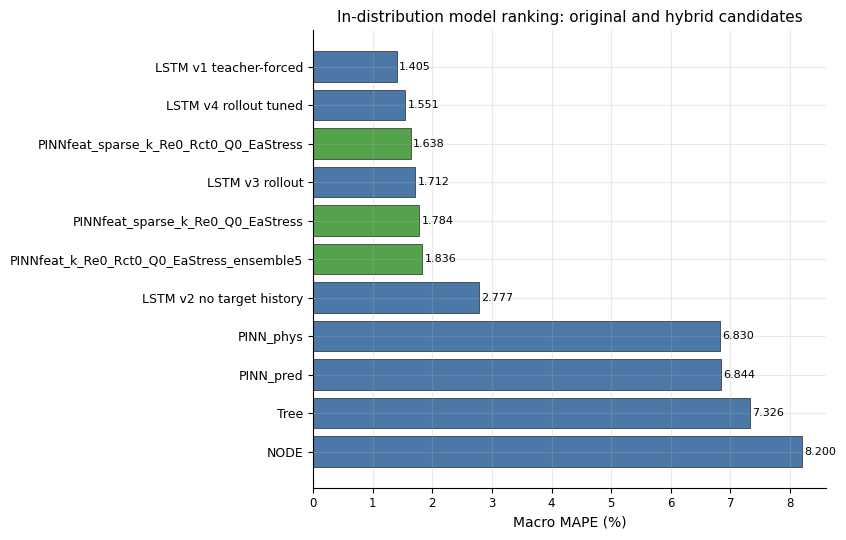

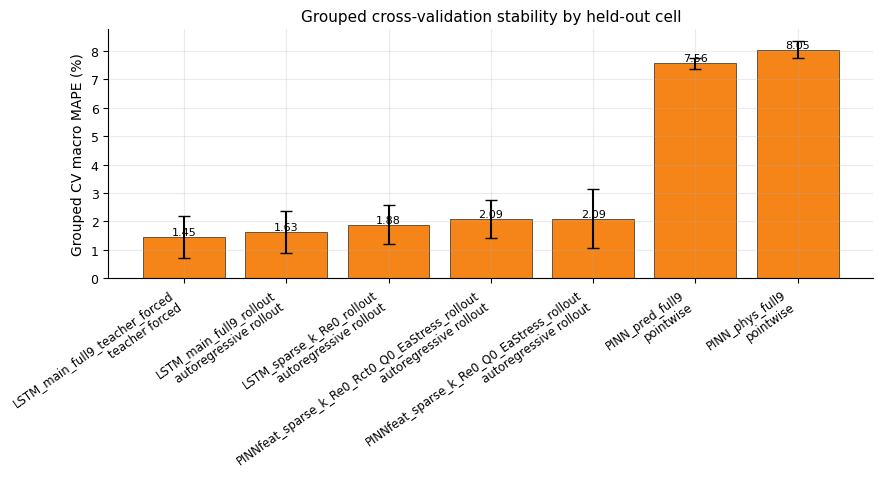

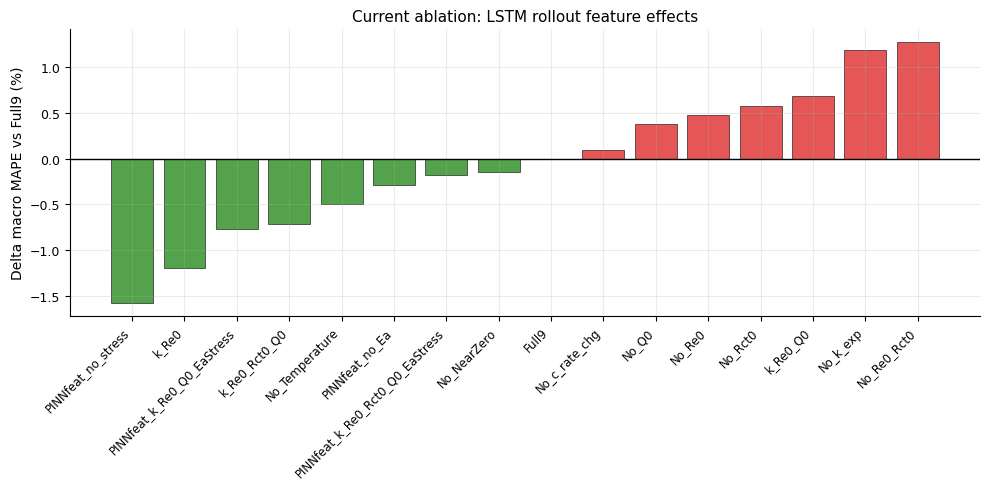

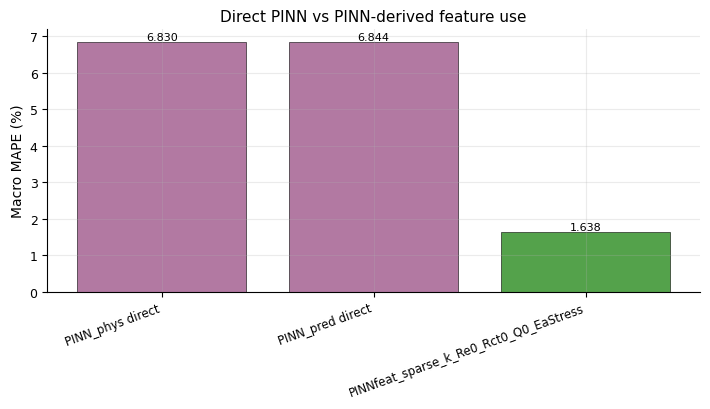

PosixPath('/kaggle/working/phase1f_paper_ready_synthesis_20260625_092740/figure_pinn_direct_vs_feature_hybrid.png')

In [25]:
def savefig(name):
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return path


# Figure 1: original + selected new results ranking.
rank_rows = []
for _, r in original.head(8).iterrows():
    rank_rows.append({"Group": "Original Phase 1", "Model": r["Model"], "MAPE": float(r["Macro_MAPE"])})
for _, r in hybrid_summary.head(4).iterrows():
    rank_rows.append({"Group": "PINN-feature hybrid", "Model": r["model"], "MAPE": float(r["MAPE"])})
rank_df = pd.DataFrame(rank_rows).sort_values("MAPE").head(12)
colors = rank_df["Group"].map({"Original Phase 1": "#4C78A8", "PINN-feature hybrid": "#54A24B"}).fillna("#777777")
plt.figure(figsize=(8.5, 5.5))
y = np.arange(len(rank_df))
plt.barh(y, rank_df["MAPE"], color=colors, edgecolor="black", linewidth=0.4)
plt.yticks(y, rank_df["Model"])
plt.xlabel("Macro MAPE (%)")
plt.title("In-distribution model ranking: original and hybrid candidates")
plt.gca().invert_yaxis()
for i, v in enumerate(rank_df["MAPE"]):
    plt.text(v + 0.04, i, f"{v:.3f}", va="center", fontsize=8)
savefig("figure_model_ranking_original_plus_hybrid.png")


# Figure 2: grouped CV stability.
cv_plot = cv_macro.sort_values("mean_MAPE").copy()
cv_plot["label"] = cv_plot["variant"] + "\n" + cv_plot["protocol"].str.replace("_", " ")
plt.figure(figsize=(9, 5))
x = np.arange(len(cv_plot))
plt.bar(x, cv_plot["mean_MAPE"], yerr=cv_plot["std_MAPE"], capsize=4, color="#F58518", edgecolor="black", linewidth=0.4)
plt.xticks(x, cv_plot["label"], rotation=35, ha="right")
plt.ylabel("Grouped CV macro MAPE (%)")
plt.title("Grouped cross-validation stability by held-out cell")
for i, v in enumerate(cv_plot["mean_MAPE"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
savefig("figure_grouped_cv_stability.png")


# Figure 3: ablation deltas for LSTM rollout.
roll = abl[(abl["model"].eq("LSTM_main")) & (abl["protocol"].eq("autoregressive_rollout"))].copy()
roll = roll.sort_values("Delta_vs_Full9")
plt.figure(figsize=(10, 5))
colors = ["#54A24B" if v <= 0 else "#E45756" for v in roll["Delta_vs_Full9"]]
plt.bar(roll["variant"], roll["Delta_vs_Full9"], color=colors, edgecolor="black", linewidth=0.4)
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Delta macro MAPE vs Full9 (%)")
plt.title("Current ablation: LSTM rollout feature effects")
savefig("figure_ablation_delta_lstm_rollout.png")


# Figure 4: PINN direct vs PINN-feature hybrid.
pinn_compare = pd.DataFrame([
    {"Model": "PINN_phys direct", "MAPE": 6.830, "Source": "Original Phase 1"},
    {"Model": "PINN_pred direct", "MAPE": 6.844, "Source": "Original Phase 1"},
    {"Model": str(hybrid_summary.iloc[0]["model"]), "MAPE": float(hybrid_summary.iloc[0]["MAPE"]), "Source": "PINN-feature LSTM"},
])
plt.figure(figsize=(7.2, 4.2))
plt.bar(pinn_compare["Model"], pinn_compare["MAPE"], color=["#B279A2", "#B279A2", "#54A24B"], edgecolor="black", linewidth=0.4)
plt.ylabel("Macro MAPE (%)")
plt.title("Direct PINN vs PINN-derived feature use")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(pinn_compare["MAPE"]):
    plt.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
savefig("figure_pinn_direct_vs_feature_hybrid.png")



## 8. Paper Claims Summary



In [26]:
claims_md = f"""# Paper-Ready Results Synthesis

Generated: {datetime.now().isoformat()}

## Main In-Distribution Claims

1. **Primary deployment model:** original Phase 1 LSTM v4 rollout-tuned remains the safest headline result at **1.551% test macro MAPE**.
2. **Grouped CV support:** cell-grouped CV preserves the same ordering: teacher-forced LSTM is the upper bound, and full-feature rollout LSTM is the strongest deployment-realistic CV model.
3. **Physics contribution:** direct PINN prediction remains weaker than LSTM, but PINN-derived descriptors (`Ea_kJ_mol_mean` and stress-style features) are useful as sparse LSTM inputs.
4. **Hybrid result:** the strongest fixed-split PINN-feature hybrid is **{hybrid_summary.iloc[0]['model']}** at **{float(hybrid_summary.iloc[0]['MAPE']):.3f}% macro MAPE**.
5. **Ablation interpretation:** current ablation supports compact BOL-state feature importance, but its retrained Full9 baseline is weaker than the original Phase 1 baseline, so use ablation deltas as relative evidence rather than replacing leaderboard numbers.

## Do Not Mix Here

Phase 4 / Kirkaldy external validation is intentionally excluded from this synthesis and should be reported separately.
"""

(OUT_DIR / "paper_claims_summary.md").write_text(claims_md, encoding="utf-8")
print(claims_md)



# Paper-Ready Results Synthesis

Generated: 2026-06-25T09:27:46.837435

## Main In-Distribution Claims

1. **Primary deployment model:** original Phase 1 LSTM v4 rollout-tuned remains the safest headline result at **1.551% test macro MAPE**.
2. **Grouped CV support:** cell-grouped CV preserves the same ordering: teacher-forced LSTM is the upper bound, and full-feature rollout LSTM is the strongest deployment-realistic CV model.
3. **Physics contribution:** direct PINN prediction remains weaker than LSTM, but PINN-derived descriptors (`Ea_kJ_mol_mean` and stress-style features) are useful as sparse LSTM inputs.
4. **Hybrid result:** the strongest fixed-split PINN-feature hybrid is **PINNfeat_sparse_k_Re0_Rct0_Q0_EaStress** at **1.638% macro MAPE**.
5. **Ablation interpretation:** current ablation supports compact BOL-state feature importance, but its retrained Full9 baseline is weaker than the original Phase 1 baseline, so use ablation deltas as relative evidence rather than replacing l

## 9. Export Zip



In [27]:
manifest = {
    "run_tag": RUN_TAG,
    "created_at": datetime.now().isoformat(),
    "sources": source_manifest,
    "excluded": "Phase 4 / Kirkaldy external validation",
    "outputs": sorted([p.name for p in OUT_DIR.glob("*")]),
}
(OUT_DIR / "phase1f_synthesis_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

zip_path = WORKING / f"{RUN_TAG}.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for f in OUT_DIR.glob("*"):
        z.write(f, arcname=f.name)

print("Zip:", zip_path)
print("Files:")
for f in sorted(OUT_DIR.glob("*")):
    print(" -", f.name)

try:
    from IPython.display import FileLink
    display(FileLink(str(zip_path)))
except Exception:
    pass


Zip: /kaggle/working/phase1f_paper_ready_synthesis_20260625_092740.zip
Files:
 - figure_ablation_delta_lstm_rollout.png
 - figure_grouped_cv_stability.png
 - figure_model_ranking_original_plus_hybrid.png
 - figure_pinn_direct_vs_feature_hybrid.png
 - paper_claims_summary.md
 - phase1f_synthesis_manifest.json
 - table_ablation_best_by_protocol.csv
 - table_current_ablation_all_macro.csv
 - table_grouped_cv.csv
 - table_hybrid_pinn_feature_results.csv
 - table_original_phase1_leaderboard.csv
 - table_paper_claims_summary.csv


/kaggle/working/phase1f_paper_ready_synthesis_20260625_092740.zip